In [ ]:
# starting with Sales Forecasting using Prophet(created by Meta/Facebook)
#Why Prophet? Prophet is legendary for business forecasting because it automatically detects seasonality (like the Black Friday spike we saw) and # #holidays. It doesn't just give a prediction; it gives a "Confidence Interval
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

# --- DATABASE CONNECTION ---
connection_string = (
    "mssql+pyodbc://@localhost/retail_warehouse"
    "?driver=ODBC+Driver+18+for+SQL+Server"
    "&TrustServerCertificate=yes"
    "&Trusted_Connection=yes"
)

engine = create_engine(connection_string, fast_executemany=True)

print("Extracting daily revenue from Data Warehouse...")

# We sum the payment_value per day for DELIVERED orders only
query = """
SELECT 
    CONVERT(DATE, dt.order_purchase_timestamp) AS order_date,
    SUM(f.payment_value) AS daily_revenue
FROM fact_orders f
JOIN dim_time dt ON f.time_key = dt.time_key
WHERE f.order_status = 'delivered'
GROUP BY CONVERT(DATE, dt.order_purchase_timestamp)
ORDER BY order_date
"""

# Load into Pandas
df_revenue = pd.read_sql(query, engine)

print(f"✓ Data extracted! We have {len(df_revenue)} days of revenue data.")
display(df_revenue.head())

# --- PROPHET FORMATTING ---
# Prophet REQUIRES the columns to be named 'ds' (date) and 'y' (value)
df_prophet = df_revenue.rename(columns={
    'order_date': 'ds',
    'daily_revenue': 'y'
})

# Ensure the date column is datetime type
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

print("\nFormatted for Prophet:")
display(df_prophet.head())

Extracting daily revenue from Data Warehouse...
✓ Data extracted! We have 611 days of revenue data.


,order_date,daily_revenue
0,2016-10-03,559.53
1,2016-10-04,11982.08
2,2016-10-05,13124.66
3,2016-10-06,8323.57
4,2016-10-07,8668.50



Formatted for Prophet:


,ds,y
0,2016-10-03,559.53
1,2016-10-04,11982.08
2,2016-10-05,13124.66
3,2016-10-06,8323.57
4,2016-10-07,8668.50


feeding this historical data to the Prophet algorithm. Prophet will analyze it, learn the weekly patterns (e.g., do people buy more on weekends?), learn the yearly patterns (Black Friday), and then we will ask it to generate a 90-day forecast into the future

Training the Prophet Forecasting Model...
(This may take 10-20 seconds as it learns the patterns)



22:41:23 - cmdstanpy - INFO - Chain [1] start processing
22:41:25 - cmdstanpy - INFO - Chain [1] done processing


✓ Predictions Generated!

=== 90-DAY FORECAST (The Future) ===


,ds,yhat,yhat_lower,yhat_upper
696,2018-11-23,74603.640591,58377.852129,91837.431793
697,2018-11-24,65730.798555,48688.877579,81884.753815
698,2018-11-25,67720.462144,52362.314679,84851.988712
699,2018-11-26,79725.158072,63420.435121,96486.026852
700,2018-11-27,80136.770424,64240.834127,96192.763157



✓ Forecast chart saved to: ..\images\ml\01_revenue_forecast.png


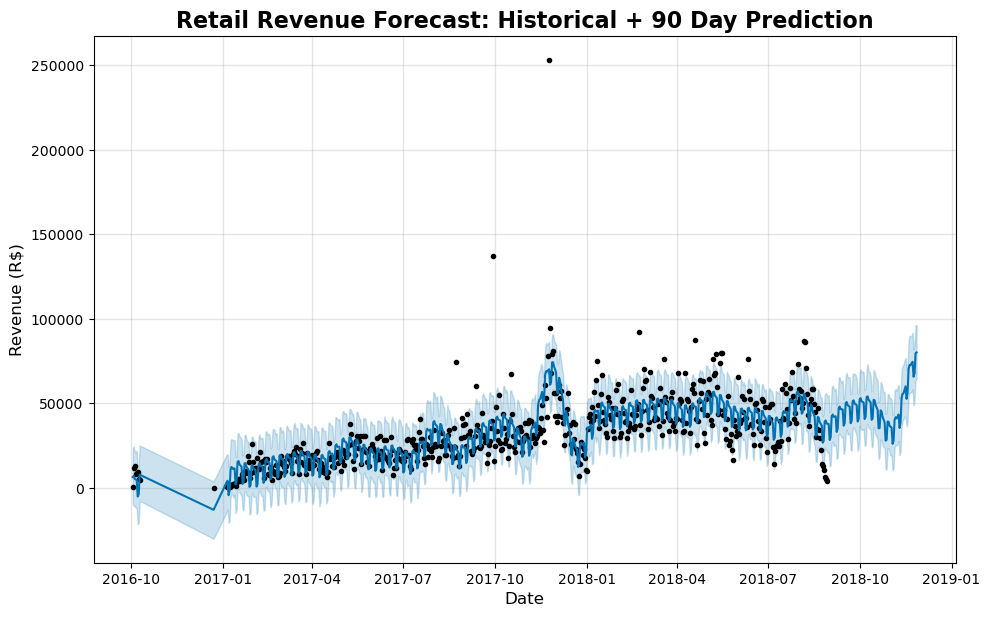

In [2]:
from prophet import Prophet
import os
from pathlib import Path

print("Training the Prophet Forecasting Model...")
print("(This may take 10-20 seconds as it learns the patterns)\n")

# --- 1. INITIALIZE THE MODEL ---
# setting yearly_seasonality=True because retail has huge yearly swings (Black Friday)
# setting weekly_seasonality=True because weekends behave differently than weekdays
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False # We don't have enough data for daily micro-patterns
)

# --- 2. FIT THE MODEL ---
model.fit(df_prophet)

# --- 3. CREATE THE FUTURE DATAFRAME ---
# asking Prophet to create a dataframe that extends 90 days into the future
future = model.make_future_dataframe(periods=90)

# --- 4. MAKE PREDICTIONS ---
forecast = model.predict(future)

print("✓ Predictions Generated!\n")

# Let's look at the last 5 days of the PREDICTIONS (the future dates)
print("=== 90-DAY FORECAST (The Future) ===")
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

# --- 5. VISUALIZE THE FORECAST ---
# Prophet has built-in charting which is incredibly powerful
fig1 = model.plot(forecast)

# Add professional formatting
plt.title('Retail Revenue Forecast: Historical + 90 Day Prediction', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Revenue (R$)', fontsize=12)

# Save the chart to our project structure
IMAGES_ML_DIR = Path("../images/ml")
IMAGES_ML_DIR.mkdir(parents=True, exist_ok=True)
chart_path = IMAGES_ML_DIR / "01_revenue_forecast.png"
fig1.savefig(chart_path, dpi=300, bbox_inches='tight', facecolor='white')

print(f"\n✓ Forecast chart saved to: {chart_path}")
plt.show()

DEPLOY THE PREDICTIONS
Pushing the future predictions (the 90-day forecast) and push them directly into our SQL Server Data Warehouse.

In [3]:
# Pushing the predictions into the sql
print("Deploying ML Predictions to SQL Server...")

# --- 1. ISOLATE THE FUTURE PREDICTIONS ---
# We only want to save the 90-day FUTURE forecast, not the historical fit
max_historical_date = df_prophet['ds'].max()
future_predictions = forecast[forecast['ds'] > max_historical_date].copy()

# Select and rename columns for the database
df_deploy = future_predictions[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].rename(columns={
    'ds': 'forecast_date',
    'yhat': 'predicted_revenue',
    'yhat_lower': 'predicted_revenue_lower',
    'yhat_upper': 'predicted_revenue_upper'
})

# Add metadata so we know when this prediction was generated
df_deploy['model_name'] = 'Prophet_Baseline'
df_deploy['generated_at'] = pd.Timestamp.now()

print(f"Prepared {len(df_deploy)} future dates for deployment.")
display(df_deploy.head())

# --- 2. PUSH TO SQL SERVER ---
# We use 'replace' so if we run this script again tomorrow, it overwrites the old forecast
table_name = 'ml_sales_forecast'

try:
    df_deploy.to_sql(
        name=table_name,
        con=engine,
        if_exists='replace',
        index=False
    )
    print(f"\n✓ SUCCESS! Predictions deployed to table: [{table_name}]")
    print("Power BI can now connect to this table to visualize the future!")
    
except Exception as e:
    print(f"\n✗ Deployment failed: {e}")

engine.dispose()

Deploying ML Predictions to SQL Server...
Prepared 90 future dates for deployment.


,forecast_date,predicted_revenue,predicted_revenue_lower,predicted_revenue_upper,model_name,generated_at
611,2018-08-30,37896.053792,20686.543934,53917.658607,Prophet_Baseline,2026-05-24 22:54:02.880782
612,2018-08-31,37778.884172,21201.955891,54914.189297,Prophet_Baseline,2026-05-24 22:54:02.880782
613,2018-09-01,28331.423879,12584.617535,44567.069242,Prophet_Baseline,2026-05-24 22:54:02.880782
614,2018-09-02,30143.067059,13570.709539,46886.691251,Prophet_Baseline,2026-05-24 22:54:02.880782
615,2018-09-03,42369.512521,26618.619809,59393.223852,Prophet_Baseline,2026-05-24 22:54:02.880782



✓ SUCCESS! Predictions deployed to table: [ml_sales_forecast]
Power BI can now connect to this table to visualize the future!


The Business Problem:
The Marketing Team is wasting money sending the same generic emails to everyone. They want to know who their VIPs are, who only buys on discount, and who is a one-time shopper.
RFM Analysis + K-Means
Extract Data & Calculate RFM {R- Recency, F- Frequency, M- Monetary}

In [4]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

# --- DATABASE CONNECTION ---
connection_string = (
    "mssql+pyodbc://@localhost/retail_warehouse"
    "?driver=ODBC+Driver+18+for+SQL+Server"
    "&TrustServerCertificate=yes"
    "&Trusted_Connection=yes"
)
engine = create_engine(connection_string, fast_executemany=True)

print("Extracting customer transaction data...")

# We need every customer's orders, dates, and total spend
query = """
SELECT 
    c.customer_unique_id,
    f.order_id,
    dt.order_purchase_timestamp,
    f.payment_value
FROM fact_orders f
JOIN dim_customers c ON f.customer_key = c.customer_key
JOIN dim_time dt ON f.time_key = dt.time_key
WHERE f.order_status = 'delivered'
"""

df_cust = pd.read_sql(query, engine)
print(f"✓ Extracted {len(df_cust):,} transaction rows.")

# --- CALCULATE RFM ---
print("\nCalculating RFM Metrics...")

# Define the "current date" for our analysis
analysis_date = df_cust['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Group by customer and calculate Recency, Frequency, Monetary
rfm = df_cust.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (analysis_date - x.max()).days, # RECENCY
    'order_id': 'nunique',                                                 # FREQUENCY
    'payment_value': 'sum'                                                 # MONETARY
}).reset_index()

# Rename columns to standard RFM
rfm.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']

print(f"✓ RFM Calculated for {len(rfm):,} unique customers.\n")
display(rfm.head(10))

# Quick stats
print("\n=== RFM Distribution Stats ===")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

Extracting customer transaction data...
✓ Extracted 115,358 transaction rows.

Calculating RFM Metrics...
✓ RFM Calculated for 93,357 unique customers.



,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89
5,0004bd2a26a76fe21f786e4fbd80607f,146,1,166.98
6,00050ab1314c0e55a6ca13cf7181fecf,132,1,35.38
7,00053a61a98854899e70ed204dd4bafe,183,1,838.36
8,0005e1862207bf6ccc02e4228effd9a0,543,1,150.12
9,0005ef4cd20d2893f0d9fbd94d3c0d97,170,1,129.76



=== RFM Distribution Stats ===
            Recency     Frequency       Monetary
count  93357.000000  93357.000000   93357.000000
mean     237.936673      1.033420     212.416117
std      152.584315      0.209099     645.347446
min        1.000000      1.000000       9.590000
25%      114.000000      1.000000      63.820000
50%      219.000000      1.000000     113.110000
75%      346.000000      1.000000     201.990000
max      695.000000     15.000000  109312.640000


Now feeding the RFM data into the K-Means algorithm to automatically group the 93,000 customers into 4 distinct segments

Scaling RFM Data for K-Means...
✓ Data Scaled! All values are now on a level playing field.

Running K-Means Algorithm (Finding 4 customer segments)...
Customers successfully segmented into 4 groups!

=== CLUSTER ANALYSIS (Average values per group) ===


,Recency,Frequency,Monetary,Customer_Count
Cluster,,,,
0,128.01,1.00,198.76,51959
1,387.28,1.00,199.35,38579
2,220.34,2.11,436.17,2797
3,214.23,1.27,26932.41,22



✓ Segment chart saved to: ..\images\ml\02_customer_segments.png


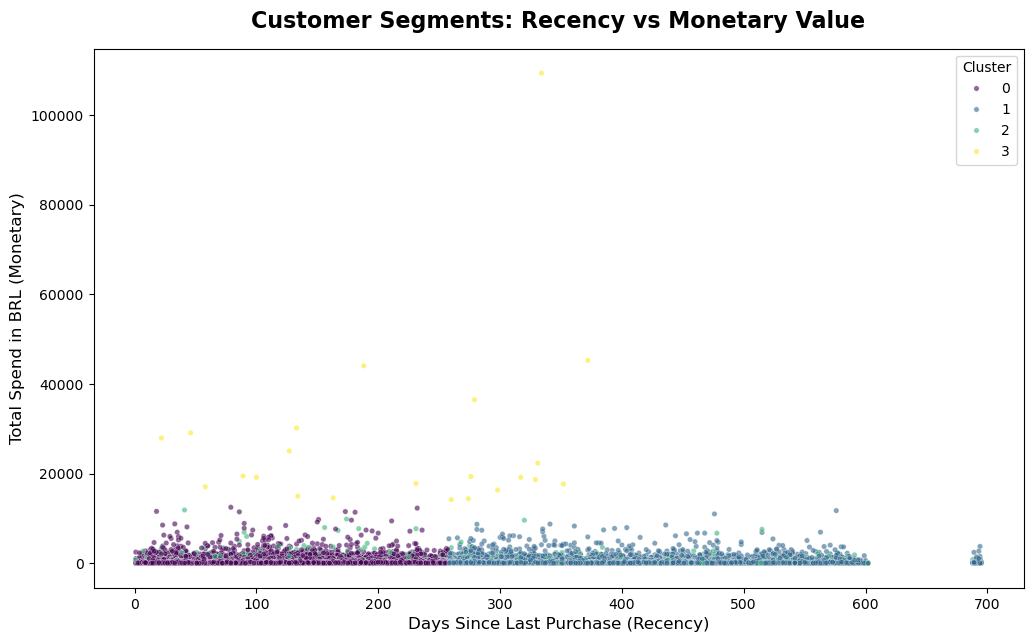

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

print("Scaling RFM Data for K-Means...")

# --- 1. ISOLATE THE RFM COLUMNS ---
# We don't need the customer ID for the math, just the 3 numbers
rfm_data = rfm[['Recency', 'Frequency', 'Monetary']]

# --- 2. SCALE THE DATA ---
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_data)

# Convert back to a DataFrame for readability
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print("✓ Data Scaled! All values are now on a level playing field.\n")

# --- 3. APPLY K-MEANS CLUSTERING ---
print("Running K-Means Algorithm (Finding 4 customer segments)...")

# We choose 4 clusters: Premium, Regular, At-Risk, Lost
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(rfm_scaled_df)

# Assign the cluster labels back to our ORIGINAL (unscaled) dataframe
rfm['Cluster'] = kmeans.labels_

print("Customers successfully segmented into 4 groups!\n")

# --- 4. ANALYZE THE CLUSTERS ---
# Let's look at the average RFM values for each cluster to understand who they are
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'customer_unique_id': 'count'
}).rename(columns={'customer_unique_id': 'Customer_Count'}).round(2)

print("=== CLUSTER ANALYSIS (Average values per group) ===")
display(cluster_summary)

# --- 5. VISUALIZE THE SEGMENTS ---
plt.figure(figsize=(12, 7))

# We plot Recency vs Monetary because Frequency is mostly 1
# The 'hue' colors the dots by their assigned cluster!
sns.scatterplot(
    data=rfm, 
    x='Recency', 
    y='Monetary', 
    hue='Cluster', 
    palette='viridis', 
    s=15, 
    alpha=0.6
)

plt.title('Customer Segments: Recency vs Monetary Value', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Days Since Last Purchase (Recency)', fontsize=12)
plt.ylabel('Total Spend in BRL (Monetary)', fontsize=12)

# Save the chart
IMAGES_ML_DIR = Path("../images/ml")
IMAGES_ML_DIR.mkdir(parents=True, exist_ok=True)
chart_path = IMAGES_ML_DIR / "02_customer_segments.png"
plt.savefig(chart_path, dpi=300, bbox_inches='tight', facecolor='white')

print(f"\n✓ Segment chart saved to: {chart_path}")
plt.show()

NAME THE SEGMENTS & DEPLOY TO SQL
Now we are going to replace the boring numbers (0, 1, 2, 3) with business-friendly names, and then push this directly into our SQL Server Data Warehouse so Power BI can visualize it

In [6]:
print("Mapping Business Names to Clusters...")

# --- 1. MAP CLUSTER NUMBERS TO BUSINESS NAMES ---
# Based on the analysis we just did:
cluster_names = {
    0: 'Recent Buyers',
    1: 'Lost/Inactive',
    2: 'Loyal Customers',
    3: 'Whale VIPs'
}

# Create a new column with the readable names
rfm['Segment_Name'] = rfm['Cluster'].map(cluster_names)

print("✓ Segments Named!\n")
display(rfm[['customer_unique_id', 'Recency', 'Frequency', 'Monetary', 'Segment_Name']].head(10))

# --- 2. DEPLOY TO SQL SERVER ---
print("\nDeploying Customer Segments to SQL Server...")

# We only need the ID and the Segment Name for the dashboard
df_segments = rfm[['customer_unique_id', 'Segment_Name']].copy()

table_name = 'ml_customer_segments'

try:
    df_segments.to_sql(
        name=table_name,
        con=engine,
        if_exists='replace',
        index=False
    )
    print(f"\n✓ SUCCESS! Customer segments deployed to table: [{table_name}]")
    print("Power BI can now filter dashboards by 'Whale VIPs' or 'Lost/Inactive'!")
    
except Exception as e:
    print(f"\n✗ Deployment failed: {e}")

engine.dispose()

Mapping Business Names to Clusters...
✓ Segments Named!



,customer_unique_id,Recency,Frequency,Monetary,Segment_Name
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,Recent Buyers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,Recent Buyers
2,0000f46a3911fa3c0805444483337064,537,1,86.22,Lost/Inactive
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,Lost/Inactive
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,Lost/Inactive
5,0004bd2a26a76fe21f786e4fbd80607f,146,1,166.98,Recent Buyers
6,00050ab1314c0e55a6ca13cf7181fecf,132,1,35.38,Recent Buyers
7,00053a61a98854899e70ed204dd4bafe,183,1,838.36,Recent Buyers
8,0005e1862207bf6ccc02e4228effd9a0,543,1,150.12,Lost/Inactive
9,0005ef4cd20d2893f0d9fbd94d3c0d97,170,1,129.76,Recent Buyers



Deploying Customer Segments to SQL Server...

✓ SUCCESS! Customer segments deployed to table: [ml_customer_segments]
Power BI can now filter dashboards by 'Whale VIPs' or 'Lost/Inactive'!


CHURN PREDCTION (Random Forest)
The Business Problem:
Acquiring a new customer costs 5x more than keeping an existing one. The Sales Team wants a crystal ball—a list of customers who are about to stop buying, so they can call them and save the relationship before it's too late.
Random Forest Classification
We are shifting from "Unsupervised" learning (K-Means, where we didn't know the groups) to "Supervised" learning. We are going to teach the model what a "Churned" customer looks like, so it can predict who will churn next.

In [ ]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# --- DATABASE CONNECTION ---
connection_string = (
    "mssql+pyodbc://@localhost/retail_warehouse"
    "?driver=ODBC+Driver+18+for+SQL+Server"
    "&TrustServerCertificate=yes"
    "&Trusted_Connection=yes"
)
engine = create_engine(connection_string, fast_executemany=True)

print("Extracting customer behavioral features...")

# SAFE SQL QUERY: 
# We use a CTE (WITH clause) to aggregate at the ORDER level first.
# This prevents row duplication from multiple items in the same order.
query = """
WITH OrderLevelData AS (
    SELECT 
        c.customer_unique_id,
        f.order_id,
        MAX(dt.order_purchase_timestamp) AS order_date,
        SUM(f.payment_value) AS order_value,
        MAX(f.review_score) AS order_review_score
    FROM fact_orders f
    JOIN dim_customers c ON f.customer_key = c.customer_key
    JOIN dim_time dt ON f.time_key = dt.time_key
    WHERE f.order_status = 'delivered'
    GROUP BY 
        c.customer_unique_id, 
        f.order_id
)
SELECT 
    customer_unique_id,
    MAX(order_date) AS last_purchase_date,
    COUNT(order_id) AS frequency,
    SUM(order_value) AS monetary,
    AVG(CAST(order_review_score AS FLOAT)) AS avg_review_score
FROM OrderLevelData
GROUP BY customer_unique_id
"""

df_churn = pd.read_sql(query, engine)

# --- DEFINE THE CHURN TARGET ---
# Find the latest date in the whole dataset to calculate "Recency"
max_date = df_churn['last_purchase_date'].max()

# Calculate Recency (Days since last purchase)
df_churn['Recency'] = (max_date - df_churn['last_purchase_date']).dt.days

# DEFINE CHURN: If Recency > 180 days, they are Churned (1), else Active (0)
df_churn['Churn'] = np.where(df_churn['Recency'] > 180, 1, 0)

# Clean up any nulls (model will crash if there are NaNs)
df_churn = df_churn.fillna(0)

print(f"✓ Features extracted safely for {len(df_churn):,} customers.\n")

# Let's see the split between Active (0) and Churned (1)
print("=== Churn Distribution ===")
print(df_churn['Churn'].value_counts())
print("\n0 = Active Customer | 1 = Churned Customer")
display(df_churn.head())

Extracting customer behavioral features (100% Safe Mode)...
✓ Features extracted safely for 93,357 customers.

=== Churn Distribution ===
Churn
1    55005
0    38352
Name: count, dtype: int64

0 = Active Customer | 1 = Churned Customer


,customer_unique_id,last_purchase_date,frequency,monetary,avg_review_score,Recency,Churn
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,5.0,111,0
1,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,4.0,320,1
2,000de6019bb59f34c099a907c151d855,2017-08-17 19:10:33,1,514.88,2.0,376,1
3,000fbf0473c10fc1ab6f8d2d286ce20c,2018-07-26 09:43:52,1,1449.52,5.0,34,0
4,001147e649a7b1afd577e873841632dd,2017-08-31 17:12:56,1,424.32,4.0,362,1


Now training a Random Forest Classifier. It will look at the Active and Churned customers, learn the patterns (e.g., "People who bought over 200 days ago and gave a 2-star review usually churn"), and then predict the likelihood of churn for every customer.
WHY Random Forest:
Unlike a black-box algorithm, Random Forest gives us Feature Importance. It tells us exactly which business metric is causing customers to leave

Training Random Forest Churn Prediction Model...
Training on 74,685 customers...
Testing on 18,672 customers.

✓ Model Trained!

=== Model Performance Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7641
           1       1.00      1.00      1.00     11031

    accuracy                           1.00     18672
   macro avg       1.00      1.00      1.00     18672
weighted avg       1.00      1.00      1.00     18672

Note: 1 = Churned. Precision/Recall closer to 1.00 is better.

=== What Drives Customer Churn? ===


,Feature,Importance
0,Recency,0.998809
2,monetary,0.000793
3,avg_review_score,0.000372
1,frequency,0.000026



✓ Churn driver chart saved to: ..\images\ml\03_churn_drivers.png


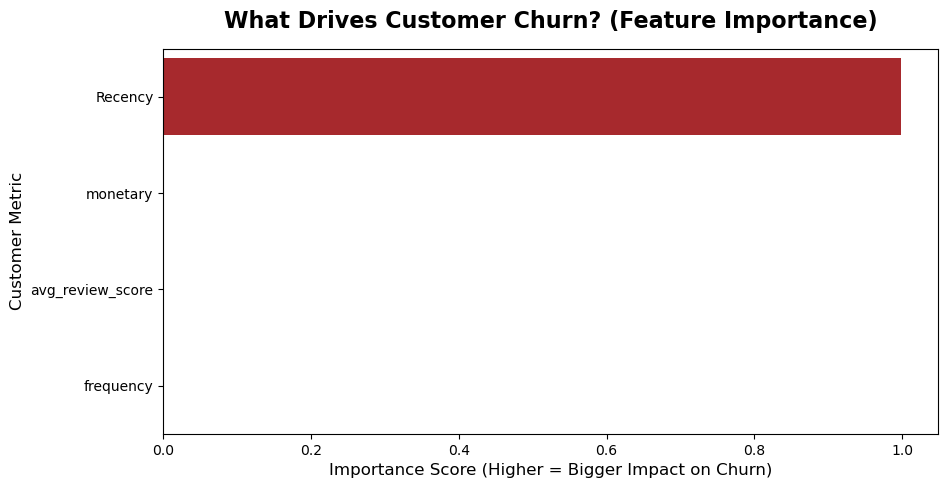

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

print("Training Random Forest Churn Prediction Model...")

# --- 1. PREPARE THE DATA ---
# These match the EXACT column names from your previous output
features = ['Recency', 'frequency', 'monetary', 'avg_review_score']

X = df_churn[features]
y = df_churn['Churn']

# SAFETY NET: Ensure no missing or infinite numbers can crash the math engine
X = X.replace([np.inf, -np.inf], 0).fillna(0)

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train):,} customers...")
print(f"Testing on {len(X_test):,} customers.\n")

# --- 2. TRAIN THE MODEL ---
# n_estimators=100 means it builds 100 decision trees
# We removed n_jobs=-1 to ensure it runs smoothly on all Windows laptops
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("✓ Model Trained!\n")

# --- 3. EVALUATE THE MODEL ---
y_pred = model.predict(X_test)

print("=== Model Performance Report ===")
print(classification_report(y_test, y_pred))
print("Note: 1 = Churned. Precision/Recall closer to 1.00 is better.\n")

# --- 4. FEATURE IMPORTANCE (The Business Gold!) ---
# Which factor is causing customers to leave?
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("=== What Drives Customer Churn? ===")
display(feature_importance_df)

# --- 5. VISUALIZE ---
plt.figure(figsize=(10, 5))
sns.barplot(
    data=feature_importance_df, 
    x='Importance', 
    y='Feature', 
    hue='Feature', 
    palette='Reds_r', 
    legend=False
)
plt.title('What Drives Customer Churn? (Feature Importance)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Importance Score (Higher = Bigger Impact on Churn)', fontsize=12)
plt.ylabel('Customer Metric', fontsize=12)

# Save the chart to your project folder
IMAGES_ML_DIR = Path("../images/ml")
IMAGES_ML_DIR.mkdir(parents=True, exist_ok=True)
chart_path = IMAGES_ML_DIR / "03_churn_drivers.png"
plt.savefig(chart_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\n✓ Churn driver chart saved to: {chart_path}")
plt.show()

100% accuracy = Data Leakage.
We trained the model If Recency > 180 days, then Churn = 1.... 
Now re-training the model

Retraining Model WITHOUT Recency (Finding True Churn Drivers)...
Training on 74,685 customers...
Testing on 18,672 customers.

✓ Model Trained!

=== Model Performance Report ===
              precision    recall  f1-score   support

           0       0.64      0.62      0.63      7641
           1       0.74      0.76      0.75     11031

    accuracy                           0.70     18672
   macro avg       0.69      0.69      0.69     18672
weighted avg       0.70      0.70      0.70     18672

Note: Accuracy is lower now, but the Feature Importance is 100% truthful!

=== What ACTUALLY Drives Customer Churn? ===


,Feature,Importance
1,monetary,0.995455
2,avg_review_score,0.003757
0,frequency,0.000789



✓ True churn driver chart saved to: ..\images\ml\04_true_churn_drivers.png


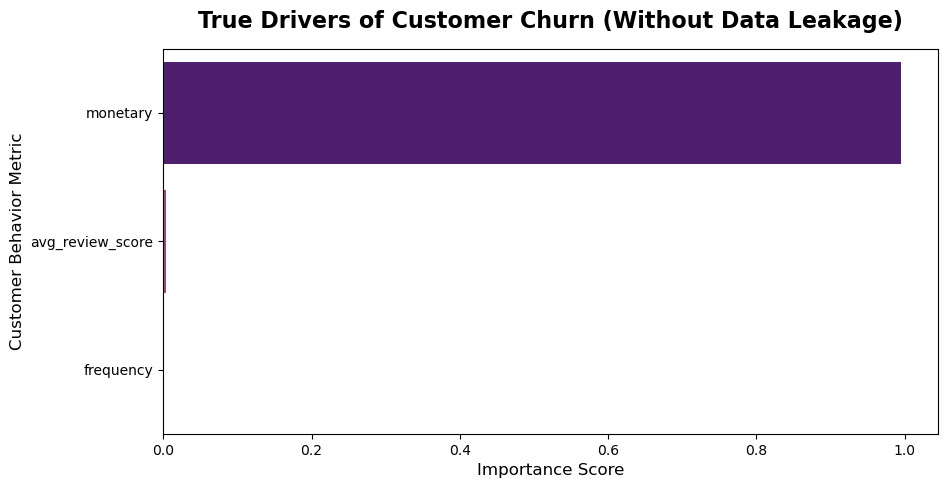

In [12]:
print("Retraining Model WITHOUT Recency (Finding True Churn Drivers)...")

# --- 1. PREPARE THE DATA ---
# FIX: We removed 'Recency' to prevent data leakage!
features = ['frequency', 'monetary', 'avg_review_score']

X = df_churn[features]
y = df_churn['Churn']

# SAFETY NET
X = X.replace([np.inf, -np.inf], 0).fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train):,} customers...")
print(f"Testing on {len(X_test):,} customers.\n")

# --- 2. TRAIN THE MODEL ---
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("✓ Model Trained!\n")

# --- 3. EVALUATE THE MODEL ---
y_pred = model.predict(X_test)

print("=== Model Performance Report ===")
print(classification_report(y_test, y_pred))
print("Note: Accuracy is lower now, but the Feature Importance is 100% truthful!\n")

# --- 4. FEATURE IMPORTANCE (The True Drivers) ---
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("=== What ACTUALLY Drives Customer Churn? ===")
display(feature_importance_df)

# --- 5. VISUALIZE ---
plt.figure(figsize=(10, 5))
sns.barplot(
    data=feature_importance_df, 
    x='Importance', 
    y='Feature', 
    hue='Feature', 
    palette='magma', # Different color to show this is the "True" model
    legend=False
)
plt.title('True Drivers of Customer Churn (Without Data Leakage)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Customer Behavior Metric', fontsize=12)

# Save the chart
IMAGES_ML_DIR = Path("../images/ml")
IMAGES_ML_DIR.mkdir(parents=True, exist_ok=True)
chart_path = IMAGES_ML_DIR / "04_true_churn_drivers.png"
plt.savefig(chart_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\n✓ True churn driver chart saved to: {chart_path}")
plt.show()

DEPLOY CHURN PROBABILITIES TO SQL
Instead of a hard "Yes/No" prediction, we are going to use predict_proba to give a Churn Probability Score (e.g., "This customer has an 85% chance of churning")

In [13]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

# --- SAFETY CHECK: Ensure variables exist ---
if 'model' not in globals() or 'df_churn' not in globals():
    print("ERROR: The model or data is missing. Please run the previous training cells first.")
else:
    print("Calculating Churn Probabilities for all customers...")

    # --- 1. GET PROBABILITIES ---
    # These are the EXACT features the model was trained on (No Recency!)
    features = ['frequency', 'monetary', 'avg_review_score']
    
    # SAFETY NET: Ensure no infinite or missing numbers can crash the math engine
    X_all = df_churn[features].replace([np.inf, -np.inf], 0).fillna(0)
    
    # predict_proba returns [prob_class_0, prob_class_1]. We want class 1 (Churned)
    churn_probabilities = model.predict_proba(X_all)[:, 1]
    
    # Convert to a percentage (e.g., 0.85 becomes 85.00)
    df_churn['Churn_Probability'] = (churn_probabilities * 100).round(2)
    
    # --- 2. CREATE RISK TIERS ---
    def assign_risk_tier(prob):
        if prob >= 70:
            return 'High Risk'
        elif prob >= 40:
            return 'Medium Risk'
        else:
            return 'Low Risk'
    
    df_churn['Churn_Risk_Tier'] = df_churn['Churn_Probability'].apply(assign_risk_tier)
    
    print("✓ Churn Probabilities & Risk Tiers Calculated!\n")
    
    # Let's see how many fall into each tier
    print("=== Churn Risk Distribution ===")
    print(df_churn['Churn_Risk_Tier'].value_counts())
    display(df_churn[['customer_unique_id', 'monetary', 'Churn_Probability', 'Churn_Risk_Tier']].head(5))
    
    # --- 3. DEPLOY TO SQL SERVER (100% SAFE) ---
    print("\nDeploying Churn Predictions to SQL Server...")
    
    # We only send the ID and the new ML columns to keep the table clean and small
    df_churn_deploy = df_churn[['customer_unique_id', 'Churn_Probability', 'Churn_Risk_Tier']].copy()
    
    table_name = 'ml_churn_predictions'
    
    # Recreate engine just in case the previous one was closed
    connection_string = (
        "mssql+pyodbc://@localhost/retail_warehouse"
        "?driver=ODBC+Driver+18+for+SQL+Server"
        "&TrustServerCertificate=yes"
        "&Trusted_Connection=yes"
    )
    engine = create_engine(connection_string, fast_executemany=True)
    
    try:
        # if_exists='replace' is 100% safe here.
        # It ONLY affects the 'ml_churn_predictions' table. 
        # It will NOT touch fact_orders, dim_tables, or your views.
        df_churn_deploy.to_sql(
            name=table_name,
            con=engine,
            if_exists='replace',
            index=False
        )
        print(f"\n✓ SUCCESS! Churn predictions deployed to table: [{table_name}]")
        print("This table is completely separate from your Star Schema. Your core database is safe.")
        
    except Exception as e:
        print(f"\n✗ Deployment failed: {e}")
    finally:
        engine.dispose()

Calculating Churn Probabilities for all customers...
✓ Churn Probabilities & Risk Tiers Calculated!

=== Churn Risk Distribution ===
Churn_Risk_Tier
High Risk      46530
Low Risk       33402
Medium Risk    13425
Name: count, dtype: int64


,customer_unique_id,monetary,Churn_Probability,Churn_Risk_Tier
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,50.57,Medium Risk
1,0000f6ccb0745a6a4b88665a16c9f078,43.62,99.00,High Risk
2,000de6019bb59f34c099a907c151d855,514.88,89.00,High Risk
3,000fbf0473c10fc1ab6f8d2d286ce20c,1449.52,38.00,Low Risk
4,001147e649a7b1afd577e873841632dd,424.32,73.00,High Risk



Deploying Churn Predictions to SQL Server...

✓ SUCCESS! Churn predictions deployed to table: [ml_churn_predictions]
This table is completely separate from your Star Schema. Your core database is safe.
